In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
import scipy as sp
from scipy.io import readsav

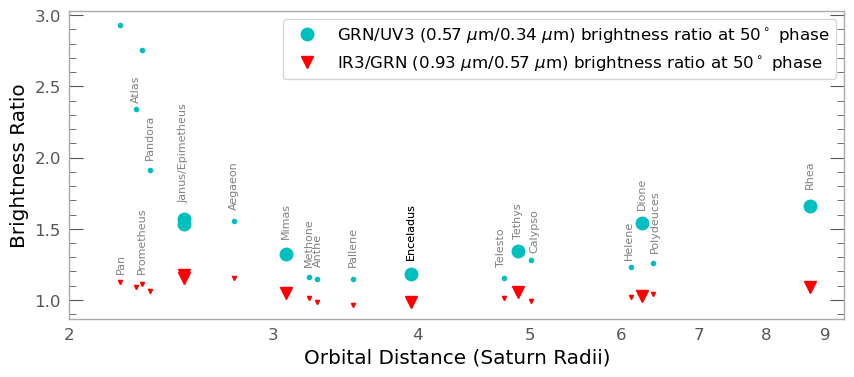

In [95]:
plt.figure(figsize=[10,4])
dat=readsav('getallcolors_err_063026.sav')
moon=dat.moon
rads=dat.rads
igcols=dat.igcols
gucols=dat.gucols
Rs=60330
size=np.array([0,0,0,0,1,1,0,1,0,0,0,1,1,0,0,1,0,0,1])
offs=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,-4,4,0,-4,4,0])
fool=(size>.5)
foos=(size<.5)
plt.plot((rads[fool]+offs[fool]*2000)/Rs, gucols[fool],'co', markersize=9,
         label='GRN/UV3 (0.57 $\mu$m/0.34 $\mu$m) brightness ratio at 50$^\circ$ phase')
plt.plot((rads[fool]+offs[fool]*2000)/Rs, igcols[fool],'rv', markersize=9, 
         label='IR3/GRN (0.93 $\mu$m/0.57 $\mu$m) brightness ratio at 50$^\circ$ phase')

plt.plot((rads[foos]+offs[foos]*2000)/Rs, igcols[foos],'rv', markersize=3)
plt.plot((rads[foos]+offs[foos]*2000)/Rs, gucols[foos],'co', markersize=3)
plt.xscale('log')
plt.xticks([2,3,4,5,6,7,8,9],labels=['2','3','4','5','6','7','8','9'])
plt.yticks([1,1.5,2,2.5,3])
plt.ylabel('Brightness Ratio')
plt.xlabel('Orbital Distance (Saturn Radii)')
plt.minorticks_on()
plt.grid(False)
plt.legend()
plt.tick_params(axis ='y', which ='major', length = 10, left=True, right=True)
plt.tick_params(axis ='y', which ='minor', length = 5, left=True, right=True)
yloc=[1.2,2.4,1.2,2,1.7,1.9,1.65,1.45,1.25,1.25,1.25,1.3,1.45,1.25,1.35,1.65,1.3,1.35,1.8]
moon=['Pan','Atlas','Prometheus','Pandora','Janus/Epimetheus',' ','Aegaeon','Mimas',
      'Methone','Anthe','Pallene','Enceladus','Tethys','Telesto','Calypso','Dione','Helene','Polydeuces','Rhea']
for i in range(len(moon)):
    plt.text((rads[i]+offs[i]*2500)/Rs,yloc[i],moon[i], rotation=90, horizontalalignment='center', alpha=.5, fontsize=8)
i=11
plt.text((rads[i]+offs[i]*2500)/Rs,yloc[i],moon[i], rotation=90, horizontalalignment='center', fontsize=8)
plt.savefig('satmooncolors_063026.pdf', bbox_inches='tight')
plt.show()
